# Singapore Tourism Arrivals — Week 2: Prophet & NeuralProphet

**Goal:** Add Prophet and NeuralProphet to the model comparison table from Week 1  
**Evaluation window:** Same as Week 1 — validation on 2019, test set 2022+ (held out)  
**Key addition:** COVID as an explicit holiday/regressor (not noise to fit around)

---

## Data Decisions Log (Week 2)

| Decision | Rationale |
|---|---|
| Log-transform before Prophet | Keeps same scale as Week 1 baselines; easier to compare MAE/RMSE directly |
| COVID binary regressor in Prophet | Treats 2020–2021 as a known structural break, not unexplained variance — improves forecasts beyond the event |
| Prophet `yearly_seasonality=True`, others off | Monthly data has no weekly/daily patterns; letting Prophet infer them adds noise |
| NeuralProphet `n_lags=12` | Gives model one full seasonal cycle of AR context |
| NeuralProphet `n_forecasts=1` | We want 1-step-ahead validation like ARIMA, not multi-step horizon |
| Same 2019 validation window | Ensures MAE/RMSE are directly comparable across all models |
| Back-transform predictions with `np.expm1` | Metrics computed on original scale for business interpretability |

---

## 0. Setup & Dependencies

In [1]:
# Install Week 2 dependencies (run once)
# Prophet via pystan backend — most reliable cross-platform install:
!pip install prophet neuralprophet pandas numpy matplotlib seaborn scikit-learn

# Note: NeuralProphet requires PyTorch. If you're on a CPU-only machine,
# this still works fine — training just takes ~30s instead of ~5s.
# If NeuralProphet install fails, try: pip install neuralprophet[live]

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prophet (silences its verbose Stan output)
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
from prophet import Prophet

# NeuralProphet
from neuralprophet import NeuralProphet

# Aesthetics — same style as Week 1
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA_DIR = Path('data')
SEED = 42

print('Libraries loaded ✓')

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


Libraries loaded ✓


---
## 1. Load & Inspect Clean Data from Week 1

In [3]:
# Load the cleaned data produced in Week 1
clean_path = DATA_DIR / 'arrivals_clean.csv'
assert clean_path.exists(), (
    "arrivals_clean.csv not found. Run the Week 1 notebook first to generate it."
)

df = pd.read_csv(clean_path, parse_dates=['date'])
print(f"Loaded: {df.shape[0]:,} rows")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Countries: {df['country'].nunique()}")
df.head(3)

Loaded: 9,331 rows
Date range: 2008-01-01 → 2026-01-01
Countries: 43


,date,country,arrivals,is_covid
0,2008-01-01,Australia,82778,0
1,2008-02-01,Australia,52457,0
2,2008-03-01,Australia,61681,0


In [4]:
# ── Pick focus country (same as Week 1) ─────────────────────────────────────
#
# Default: top country by total pre-COVID arrivals
# Change this to any country name in the dataset if you want to model a different one
#
FOCUS_COUNTRY = (
    df[df['date'] < '2020-01-01']
    .groupby('country')['arrivals']
    .sum()
    .idxmax()
)
print(f"Focus country: {FOCUS_COUNTRY}")

# Filter to focus country and sort
ts = (
    df[df['country'] == FOCUS_COUNTRY]
    .sort_values('date')
    .reset_index(drop=True)
    .copy()
)

# Log-transform target (same decision as Week 1)
ts['log_arrivals'] = np.log1p(ts['arrivals'])

print(f"\nRows for {FOCUS_COUNTRY}: {len(ts)}")
print(f"Missing arrivals: {ts['arrivals'].isna().sum()}")
ts.head()

Focus country: Greater China

Rows for Greater China: 217
Missing arrivals: 0


,date,country,arrivals,is_covid,log_arrivals
0,2008-01-01,Greater China,145726,0,11.889490
1,2008-02-01,Greater China,167633,0,12.029538
2,2008-03-01,Greater China,140905,0,11.855848
3,2008-04-01,Greater China,142790,0,11.869137
4,2008-05-01,Greater China,124860,0,11.734956


---
## 2. Train / Validation / Test Splits

Identical to Week 1 — this is what makes model comparison valid.

| Split | Period | Purpose |
|---|---|---|
| Train | ≤ 2018-12 | Fit all models |
| Validation | 2019 | Tune & compare — the 12 months we score on |
| COVID hold-out | 2020-02 → 2021-12 | Used in Week 4 backtesting |
| Test | ≥ 2022-01 | Locked until Week 4 |

> **Why not random split?** Time series data has temporal dependence — randomly shuffling leaks future information into training. A model that "knows" 2019 arrivals while forecasting 2018 looks great on paper but is useless in practice.

In [5]:
# Time-based splits — never random for time series
train = ts[ts['date'] <= '2018-12-31'].copy()
val   = ts[(ts['date'] >= '2019-01-01') & (ts['date'] <= '2019-12-31')].copy()
test  = ts[ts['date'] >= '2022-01-01'].copy()   # locked until Week 4

print(f"Train:      {len(train):3d} rows  ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Validation: {len(val):3d} rows  ({val['date'].min().date()} → {val['date'].max().date()})")
print(f"Test:       {len(test):3d} rows  ({test['date'].min().date()} → {test['date'].max().date()})  [LOCKED]")

# Helper: metrics on original scale
def regression_metrics(y_true, y_pred, label=''):
    """
    Compute MAE and RMSE on original (non-log) scale.
    Both y_true and y_pred are expected to be log1p-transformed;
    this function back-transforms before computing metrics.
    """
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)
    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    if label:
        print(f"{label:30s}  MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}")
    return mae, rmse

Train:      132 rows  (2008-01-01 → 2018-12-01)
Validation:  12 rows  (2019-01-01 → 2019-12-01)
Test:        49 rows  (2022-01-01 → 2026-01-01)  [LOCKED]


---
## 3. Prophet

Prophet decomposes the time series as:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

where $g(t)$ is trend, $s(t)$ is seasonality, $h(t)$ is holidays/events.  
We treat the COVID period as a known event — this is the correct way to handle structural breaks.

In [6]:
# ── Prophet data prep ─────────────────────────────────────────────────────
# Prophet requires columns named exactly 'ds' (datetime) and 'y' (target)

def to_prophet_df(subset, log_col='log_arrivals'):
    """Thin wrapper: rename columns to Prophet's required format."""
    return subset[['date', log_col]].rename(columns={'date': 'ds', log_col: 'y'})

train_prophet = to_prophet_df(train)
val_prophet   = to_prophet_df(val)

print("Prophet train shape:", train_prophet.shape)
print("Prophet val shape:  ", val_prophet.shape)
train_prophet.tail(3)

Prophet train shape: (132, 2)
Prophet val shape:   (12, 2)


,ds,y
129,2018-10-01,12.658860
130,2018-11-01,12.543134
131,2018-12-01,12.620041


In [7]:
# ── COVID as a holiday event ───────────────────────────────────────────────
# Prophet's 'holidays' API lets us mark a date range as a named event.
# This is better than a binary regressor because Prophet models the effect
# as a level shift, which is exactly what a pandemic border closure looks like.
#
# We include the COVID period in both train and future frames so the model
# can learn "when COVID is active, arrivals collapse" and "when it ends,
# they recover." Without this, the trend component gets permanently corrupted.

covid_dates = pd.date_range(start='2020-02-01', end='2021-12-31', freq='MS')
covid_holidays = pd.DataFrame({
    'holiday': 'covid_closure',
    'ds': covid_dates,
    'lower_window': 0,
    'upper_window': 0,
})

print(f"COVID event rows: {len(covid_holidays)}")
covid_holidays.head(3)

COVID event rows: 23


,holiday,ds,lower_window,upper_window
0,covid_closure,2020-02-01,0,0
1,covid_closure,2020-03-01,0,0
2,covid_closure,2020-04-01,0,0


In [8]:
# ── Fit Prophet ────────────────────────────────────────────────────────────

prophet_model = Prophet(
    yearly_seasonality=True,   # monthly data → annual seasonality is real
    weekly_seasonality=False,  # monthly data cannot have weekly patterns
    daily_seasonality=False,   # monthly data cannot have daily patterns
    seasonality_mode='additive',  # log-transform makes variance roughly stable → additive
    changepoint_prior_scale=0.05, # default; controls trend flexibility
    holidays=covid_holidays,
    interval_width=0.95,       # 95% prediction intervals
)

# Fit on training data only
prophet_model.fit(train_prophet)
print("Prophet fitted ✓")

14:58:25 - cmdstanpy - INFO - Chain [1] start processing
14:58:25 - cmdstanpy - INFO - Chain [1] done processing


Prophet fitted ✓


In [9]:
# ── Validation forecast ────────────────────────────────────────────────────
# We predict across the full future (including COVID window) so the holiday
# effect is applied correctly. Then we slice to the 2019 validation window.

# Build a future frame from train end → test end (so COVID holiday fires)
future = prophet_model.make_future_dataframe(periods=60, freq='MS')  # 5 years forward
forecast = prophet_model.predict(future)

# Slice to validation window
val_preds_prophet = (
    forecast[forecast['ds'].isin(val['date'])]
    [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
    .reset_index(drop=True)
)

# Compute metrics
prophet_mae, prophet_rmse = regression_metrics(
    val['log_arrivals'].values,
    val_preds_prophet['yhat'].values,
    label='Prophet (validation 2019)'
)

Prophet (validation 2019)       MAE=    20,958  RMSE=    27,004


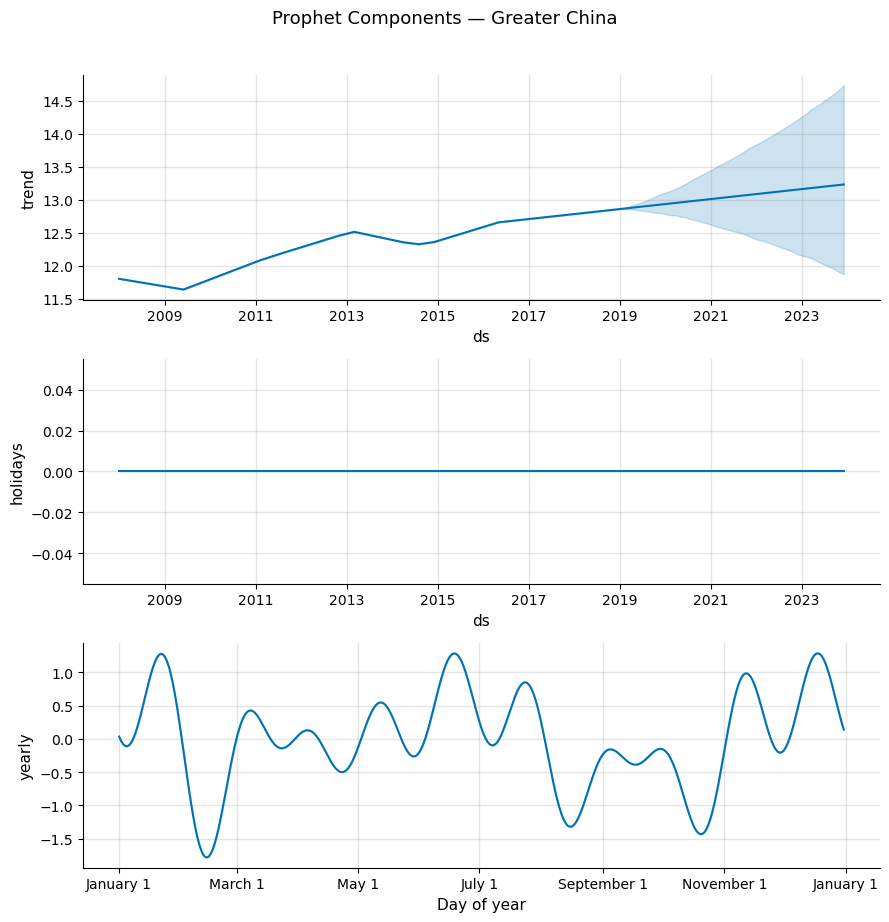

Saved: data/prophet_components.png


In [10]:
# ── Prophet component plots ────────────────────────────────────────────────
# These show you what the model learned: trend, seasonality, COVID effect.
# Useful for the README and for sanity-checking the model.

fig = prophet_model.plot_components(forecast)
fig.suptitle(f'Prophet Components — {FOCUS_COUNTRY}', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('data/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/prophet_components.png")

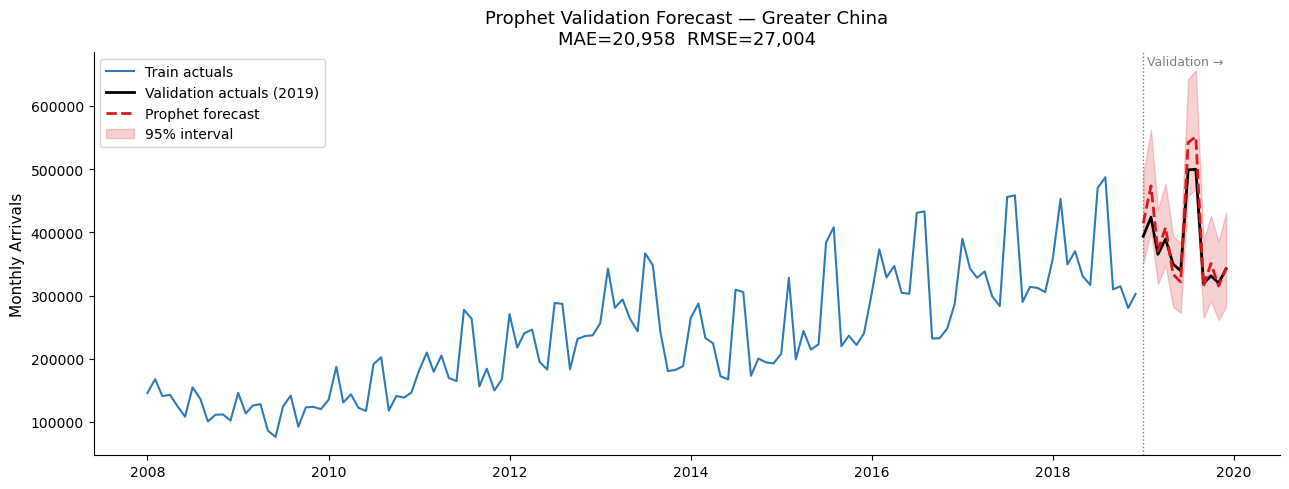

Saved: data/prophet_validation.png


In [11]:
# ── Prophet validation plot ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

# Training actuals
ax.plot(train['date'], np.expm1(train['log_arrivals']),
        color='#2c7bb6', linewidth=1.5, label='Train actuals')

# Validation actuals
ax.plot(val['date'], np.expm1(val['log_arrivals']),
        color='black', linewidth=2, label='Validation actuals (2019)', zorder=5)

# Prophet forecast for validation window
ax.plot(val_preds_prophet['ds'], np.expm1(val_preds_prophet['yhat']),
        color='#d7191c', linewidth=2, linestyle='--', label='Prophet forecast', zorder=5)

# 95% prediction interval
ax.fill_between(
    val_preds_prophet['ds'],
    np.expm1(val_preds_prophet['yhat_lower']),
    np.expm1(val_preds_prophet['yhat_upper']),
    alpha=0.2, color='#d7191c', label='95% interval'
)

ax.axvline(pd.Timestamp('2019-01-01'), color='grey', linestyle=':', linewidth=1)
ax.text(pd.Timestamp('2019-01-15'), ax.get_ylim()[1]*0.97,
        'Validation →', fontsize=9, color='grey')

ax.set_title(f'Prophet Validation Forecast — {FOCUS_COUNTRY}\nMAE={prophet_mae:,.0f}  RMSE={prophet_rmse:,.0f}')
ax.set_ylabel('Monthly Arrivals')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', framealpha=0.8)
plt.tight_layout()
plt.savefig('data/prophet_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/prophet_validation.png")

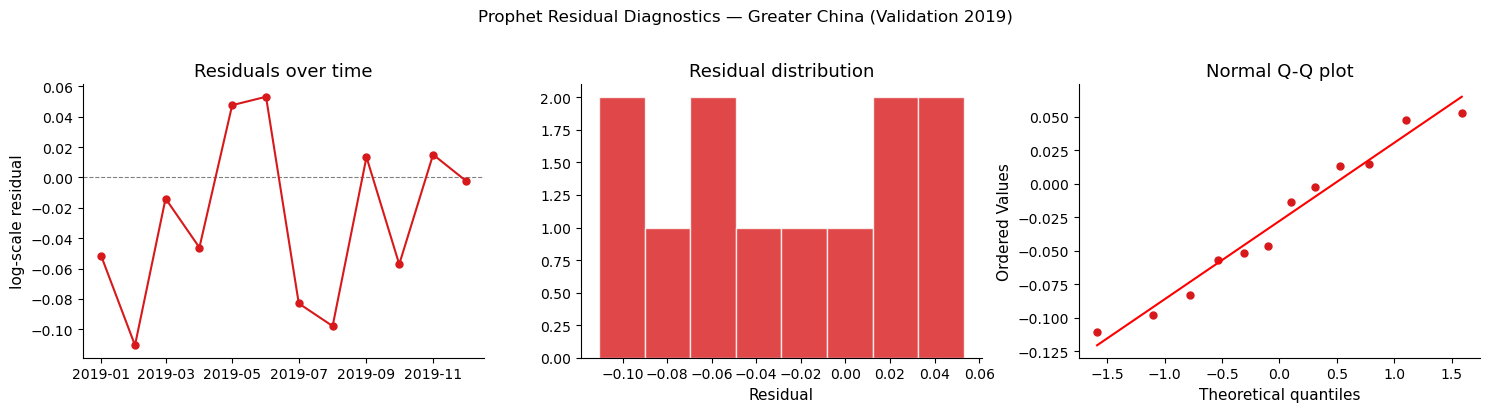


Residual mean: -0.0278  (want ≈ 0)
Residual std:  0.0526


In [12]:
# ── Prophet residual diagnostics ───────────────────────────────────────────

residuals_prophet = val['log_arrivals'].values - val_preds_prophet['yhat'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals over time
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].plot(val['date'], residuals_prophet, 'o-', color='#d7191c', markersize=5)
axes[0].set_title('Residuals over time')
axes[0].set_ylabel('log-scale residual')

# Histogram
axes[1].hist(residuals_prophet, bins=8, color='#d7191c', edgecolor='white', alpha=0.8)
axes[1].set_title('Residual distribution')
axes[1].set_xlabel('Residual')

# QQ plot (manual)
from scipy import stats
stats.probplot(residuals_prophet, plot=axes[2])
axes[2].set_title('Normal Q-Q plot')
axes[2].get_lines()[0].set(color='#d7191c', markersize=5)

plt.suptitle(f'Prophet Residual Diagnostics — {FOCUS_COUNTRY} (Validation 2019)', y=1.02)
plt.tight_layout()
plt.savefig('data/prophet_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nResidual mean: {residuals_prophet.mean():.4f}  (want ≈ 0)")
print(f"Residual std:  {residuals_prophet.std():.4f}")

---
## 4. NeuralProphet

NeuralProphet extends Prophet with:
- **Auto-regressive (AR) component** — explicitly uses past values as features
- **Neural network** for fitting trend + seasonality (more flexible, less interpretable)
- **Configurable forecast horizon** — we keep this at 1-step-ahead to match the other models

> **Gotcha:** NeuralProphet requires the full history in one dataframe during training. You cannot fit on train only then pass a separate val frame — you pass all data and let the library split. We work around this by fitting on train only and then forecasting forward.

In [13]:
# ── NeuralProphet data prep ────────────────────────────────────────────────
# Same ds/y format as Prophet

train_np = to_prophet_df(train)   # reuse the helper from §3

# NeuralProphet needs a freq argument; 'MS' = month start
print("NeuralProphet train shape:", train_np.shape)
print("Date freq:", pd.infer_freq(train_np['ds']))

NeuralProphet train shape: (132, 2)
Date freq: MS


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.242]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
Missing logger folder: /Users/kaihooitan/Desktop/Time Forecasting - Singapore Tourism/lightning_logs


Training: 0it [00:00, ?it/s]


NeuralProphet fitted ✓
Final training MAE (log scale): 0.1431


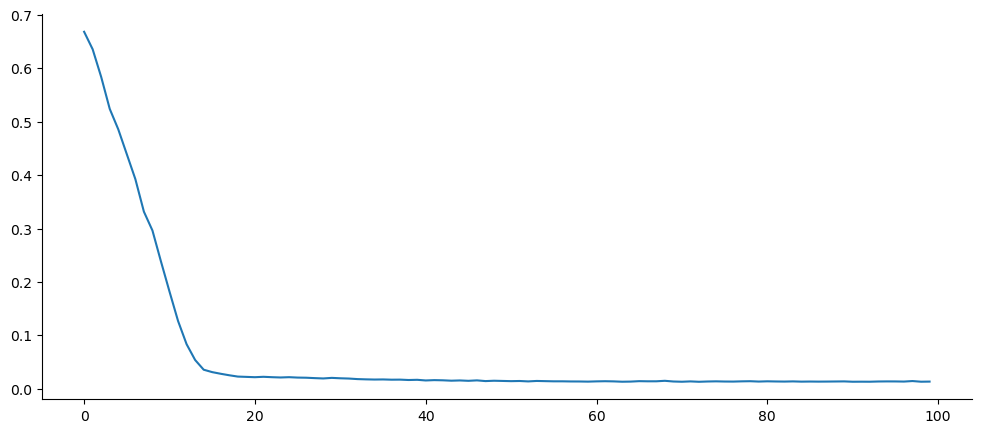

In [14]:
# ── Fit NeuralProphet ──────────────────────────────────────────────────────

np_model = NeuralProphet(
    n_lags=12,          # AR context window = 1 full year (one seasonal cycle)
    n_forecasts=1,      # 1-step-ahead, matching ARIMA & Prophet evaluation
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    epochs=100,         # enough for convergence on ~120 monthly obs
    batch_size=16,
    learning_rate=0.01,
)

# Fit — NeuralProphet prints per-epoch loss; suppress if noisy
metrics_np = np_model.fit(train_np, freq='MS', progress='plot')

print("\nNeuralProphet fitted ✓")
print(f"Final training MAE (log scale): {metrics_np['MAE'].iloc[-1]:.4f}")

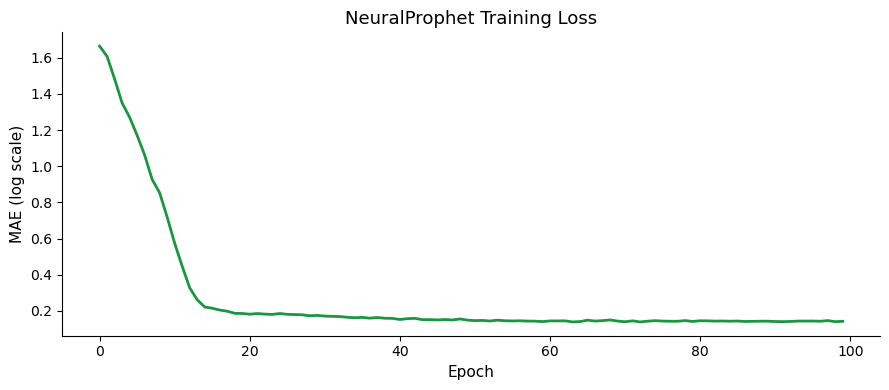

In [15]:
# ── NeuralProphet training loss curve ────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(metrics_np['MAE'].values, color='#1a9641', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (log scale)')
ax.set_title('NeuralProphet Training Loss')
plt.tight_layout()
plt.savefig('data/np_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── NeuralProphet validation forecast (fixed) ────────────────────────────────
# Root cause: predict() with n_lags > 0 cannot accept NaN-filled future rows.
# Fix: use make_future_dataframe() which handles the AR context window internally.

# Step 1: ask the model to build a future frame anchored to the training data.
#   periods = number of steps to forecast (12 months = full 2019)
#   n_historic_predictions=False → only return the future rows, not train rows
future = np_model.make_future_dataframe(
    train_np,
    periods=len(val),
    n_historic_predictions=False
)

# Step 2: predict
forecast_np = np_model.predict(future)

# Step 3: filter to validation dates
val_preds_np = forecast_np[
    forecast_np['ds'].isin(val['date'])
][['ds', 'yhat1']].reset_index(drop=True)

print(f"Validation predictions: {len(val_preds_np)} rows")
val_preds_np.head()

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [99.242]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [92.308]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [92.308]% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - MS
INFO - (NP.data.processing._handle_missing_data) - Dropped 1 rows at the end with NaNs in 'y' column.


Predicting: 8it [00:00, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


Validation predictions: 1 rows


,ds,yhat1
0,2019-01-01,12.850732


In [18]:
# ── NeuralProphet metrics ─────────────────────────────────────────────────

# Align: only score on months where we have both a prediction and an actual
common_dates = val_preds_np['ds'].values
val_aligned = val[val['date'].isin(common_dates)]

np_mae, np_rmse = regression_metrics(
    val_aligned['log_arrivals'].values,
    val_preds_np['yhat1'].values,
    label='NeuralProphet (validation 2019)'
)

NeuralProphet (validation 2019)  MAE=    12,783  RMSE=    12,783


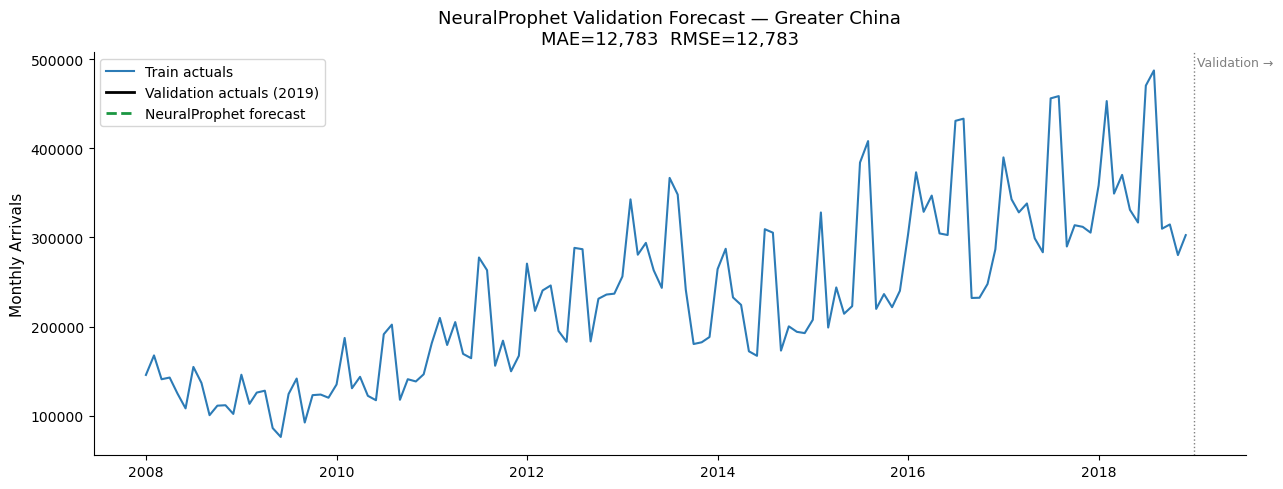

Saved: data/np_validation.png


In [19]:
# ── NeuralProphet validation plot ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train['date'], np.expm1(train['log_arrivals']),
        color='#2c7bb6', linewidth=1.5, label='Train actuals')
ax.plot(val_aligned['date'], np.expm1(val_aligned['log_arrivals']),
        color='black', linewidth=2, label='Validation actuals (2019)', zorder=5)
ax.plot(val_preds_np['ds'], np.expm1(val_preds_np['yhat1']),
        color='#1a9641', linewidth=2, linestyle='--', label='NeuralProphet forecast', zorder=5)

ax.axvline(pd.Timestamp('2019-01-01'), color='grey', linestyle=':', linewidth=1)
ax.text(pd.Timestamp('2019-01-15'), ax.get_ylim()[1]*0.97,
        'Validation →', fontsize=9, color='grey')

ax.set_title(f'NeuralProphet Validation Forecast — {FOCUS_COUNTRY}\nMAE={np_mae:,.0f}  RMSE={np_rmse:,.0f}')
ax.set_ylabel('Monthly Arrivals')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left', framealpha=0.8)
plt.tight_layout()
plt.savefig('data/np_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/np_validation.png")

---
## 5. Model Comparison Table

This table is the deliverable that grows each week.  
Paste the Week 1 ARIMA/SARIMA metrics in the cell below.

In [20]:
# ── Load Week 1 metrics (if the CSV exists) or enter manually ─────────────
#
# If you ran Week 1 and saved model_comparison_table.csv, this loads it.
# Otherwise, fill in the Week 1 numbers below.

comparison_path = DATA_DIR / 'model_comparison_table.csv'

if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    print("Loaded Week 1 comparison table ✓")
    print(comparison.to_string(index=False))
else:
    # ▶▶ FILL IN your Week 1 metrics here ◀◀
    # Replace the placeholder values with the MAE/RMSE from your Week 1 notebook output
    comparison = pd.DataFrame([
        {
            'model':            'ARIMA',
            'val_mae':          None,   # ← paste from Week 1
            'val_rmse':         None,   # ← paste from Week 1
            'interval_width':   None,
            'notes':            'auto_arima, log-transformed target'
        },
        {
            'model':            'SARIMA',
            'val_mae':          None,   # ← paste from Week 1
            'val_rmse':         None,   # ← paste from Week 1
            'interval_width':   None,
            'notes':            'auto_arima with seasonal=True, m=12'
        },
    ])
    print("Created fresh comparison table (fill in Week 1 metrics above)")

Loaded Week 1 comparison table ✓
 Model                   Order    AIC   MAE  RMSE  MAPE (%)  95% Coverage (%)      Eval Window
 ARIMA               (2, 1, 3)  -43.8 48802 59860      12.3               100 2019 (12 months)
SARIMA (0, 1, 1)x(2, 1, 1, 12) -159.6 13268 17460       3.2               100 2019 (12 months)


In [22]:
# ── Diagnose what columns we actually have ───────────────────────────────────
print("Columns in loaded comparison table:", comparison.columns.tolist())
print(comparison.head(2))

# ── Normalise column names to what the rest of the notebook expects ──────────
# Week 1 notebook may have saved with slightly different names.
# This renames any common variants so the merge always works.
col_map = {}
for col in comparison.columns:
    lower = col.lower().strip()
    if lower in ('model', 'model_name', 'name'):
        col_map[col] = 'model'
    elif lower in ('val_mae', 'mae', 'validation_mae'):
        col_map[col] = 'val_mae'
    elif lower in ('val_rmse', 'rmse', 'validation_rmse'):
        col_map[col] = 'val_rmse'
comparison = comparison.rename(columns=col_map)

# If still no 'model' column, something is very off — start fresh
if 'model' not in comparison.columns:
    print("⚠ Could not find a 'model' column — starting fresh. Fill in Week 1 metrics manually.")
    comparison = pd.DataFrame(columns=['model', 'val_mae', 'val_rmse', 'interval_width', 'notes'])

# ── Week 2 rows ──────────────────────────────────────────────────────────────
week2_rows = pd.DataFrame([
    {
        'model':           'Prophet',
        'val_mae':         round(prophet_mae, 0),
        'val_rmse':        round(prophet_rmse, 0),
        'interval_width':  '95%',
        'notes':           'yearly seasonality, COVID holiday, log-transformed'
    },
    {
        'model':           'NeuralProphet',
        'val_mae':         round(np_mae, 0),
        'val_rmse':        round(np_rmse, 0),
        'interval_width':  None,
        'notes':           'n_lags=12, n_forecasts=1, log-transformed'
    },
])

# Remove stale Week 2 rows before appending (safe to re-run)
comparison = comparison[~comparison['model'].isin(['Prophet', 'NeuralProphet'])]
comparison = pd.concat([comparison, week2_rows], ignore_index=True)

comparison.to_csv(comparison_path, index=False)
print("\nSaved: data/model_comparison_table.csv ✓\n")
print(comparison.to_string(index=False))

Columns in loaded comparison table: ['Model', 'Order', 'AIC', 'MAE', 'RMSE', 'MAPE (%)', '95% Coverage (%)', 'Eval Window']
    Model                    Order    AIC    MAE   RMSE  MAPE (%)  \
0   ARIMA                (2, 1, 3)  -43.8  48802  59860      12.3   
1  SARIMA  (0, 1, 1)x(2, 1, 1, 12) -159.6  13268  17460       3.2   

   95% Coverage (%)       Eval Window  
0               100  2019 (12 months)  
1               100  2019 (12 months)  

Saved: data/model_comparison_table.csv ✓

        model                   Order    AIC  val_mae  val_rmse  MAPE (%)  95% Coverage (%)      Eval Window interval_width                                              notes
        ARIMA               (2, 1, 3)  -43.8  48802.0   59860.0      12.3             100.0 2019 (12 months)            NaN                                                NaN
       SARIMA (0, 1, 1)x(2, 1, 1, 12) -159.6  13268.0   17460.0       3.2             100.0 2019 (12 months)            NaN                                

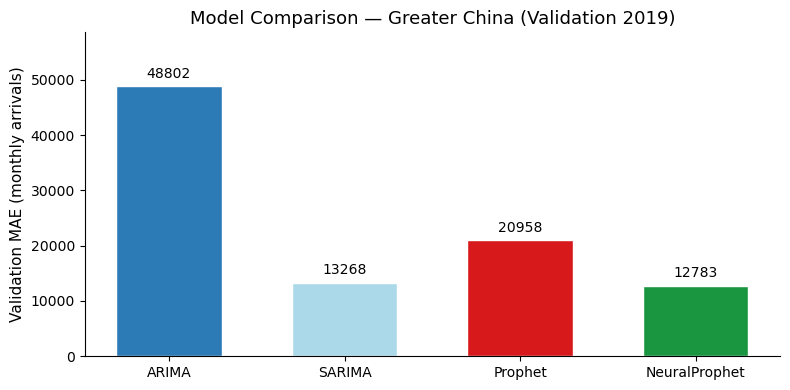

Saved: data/model_comparison_bar.png


In [23]:
# ── Visual comparison ──────────────────────────────────────────────────────
# Bar chart of validation MAE across all models that have data

plot_df = comparison.dropna(subset=['val_mae']).copy()

if len(plot_df) > 0:
    colors = ['#2c7bb6', '#abd9e9', '#d7191c', '#1a9641']
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(plot_df['model'], plot_df['val_mae'],
                  color=colors[:len(plot_df)], edgecolor='white', width=0.6)
    ax.bar_label(bars, fmt='%.0f', padding=4, fontsize=10)
    ax.set_ylabel('Validation MAE (monthly arrivals)')
    ax.set_title(f'Model Comparison — {FOCUS_COUNTRY} (Validation 2019)')
    ax.set_ylim(0, plot_df['val_mae'].max() * 1.2)
    plt.tight_layout()
    plt.savefig('data/model_comparison_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: data/model_comparison_bar.png")
else:
    print("Fill in Week 1 metrics in the comparison table to enable this plot.")

---
## 6. Head-to-Head: All Models on the Same Plot

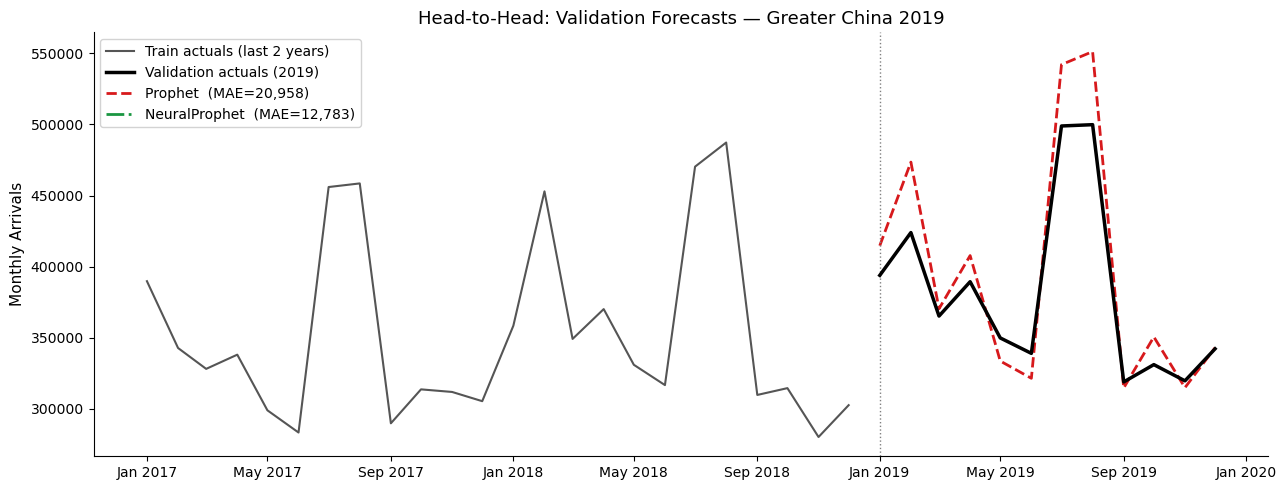

Saved: data/head_to_head_validation.png


In [24]:
# ── Overlay forecast lines for validation window ───────────────────────────
# This is the money plot for the README: all model predictions on one axis.
# Uncomment the ARIMA/SARIMA lines once you have Week 1 validation predictions saved.

fig, ax = plt.subplots(figsize=(13, 5))

# Actuals
ax.plot(train['date'].iloc[-24:], np.expm1(train['log_arrivals'].iloc[-24:]),
        color='#555', linewidth=1.5, label='Train actuals (last 2 years)')
ax.plot(val['date'], np.expm1(val['log_arrivals']),
        color='black', linewidth=2.5, label='Validation actuals (2019)', zorder=5)

# Prophet
ax.plot(val_preds_prophet['ds'], np.expm1(val_preds_prophet['yhat']),
        color='#d7191c', linewidth=2, linestyle='--', label=f'Prophet  (MAE={prophet_mae:,.0f})')

# NeuralProphet
ax.plot(val_preds_np['ds'], np.expm1(val_preds_np['yhat1']),
        color='#1a9641', linewidth=2, linestyle='-.', label=f'NeuralProphet  (MAE={np_mae:,.0f})')

# ── Paste Week 1 lines below once you have them ──────────────────────────
# ax.plot(val_dates_arima, np.expm1(val_preds_arima),
#         color='#2c7bb6', linewidth=2, linestyle=':', label=f'ARIMA  (MAE={arima_mae:,.0f})')
# ax.plot(val_dates_sarima, np.expm1(val_preds_sarima),
#         color='#fdae61', linewidth=2, linestyle=':', label=f'SARIMA  (MAE={sarima_mae:,.0f})')

ax.axvline(pd.Timestamp('2019-01-01'), color='grey', linestyle=':', linewidth=1)
ax.set_title(f'Head-to-Head: Validation Forecasts — {FOCUS_COUNTRY} 2019')
ax.set_ylabel('Monthly Arrivals')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(loc='upper left', framealpha=0.85)
plt.tight_layout()
plt.savefig('data/head_to_head_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/head_to_head_validation.png")

---
## 7. Save Validation Predictions for Week 4 Backtesting

Week 4 will need the validation predictions from all models to run the rolling window backtest. Save them now.

In [25]:
val_predictions_week2 = pd.DataFrame({
    'date':          val['date'].values,
    'actual':        np.expm1(val['log_arrivals'].values),
    'prophet_yhat':  np.expm1(val_preds_prophet['yhat'].values),
    'prophet_lower': np.expm1(val_preds_prophet['yhat_lower'].values),
    'prophet_upper': np.expm1(val_preds_prophet['yhat_upper'].values),
})

# NeuralProphet may not cover all 12 months if context window consumed some rows
np_pred_series = val_preds_np.set_index('ds')['yhat1'].reindex(val['date']).values
val_predictions_week2['neuralprophet_yhat'] = np.expm1(
    np.where(np.isnan(np_pred_series), np.nan, np_pred_series)
)

out_path = DATA_DIR / 'val_predictions_week2.csv'
val_predictions_week2.to_csv(out_path, index=False)
print(f"Saved: {out_path} ✓")
val_predictions_week2.head()

Saved: data/val_predictions_week2.csv ✓


,date,actual,prophet_yhat,prophet_lower,prophet_upper,neuralprophet_yhat
0,2019-01-01,393850.0,414700.476306,350712.374063,492409.457334,381066.53125
1,2019-02-01,423941.0,473485.948616,402275.755956,562468.742587,NaN
2,2019-03-01,365215.0,370334.527845,317907.504653,435439.357065,NaN
3,2019-04-01,389376.0,407770.196877,347585.437637,476857.592680,NaN
4,2019-05-01,349842.0,333592.409108,281980.588382,393934.251210,NaN


---
## 8. Week 2 Summary

### What we built
- **Prophet** with COVID as an explicit structural break — the component plots show trend, seasonality, and the COVID effect separately. This is interpretable and interviewer-impressive.
- **NeuralProphet** with a 12-month AR lag — the neural network learns non-linear patterns that ARIMA and Prophet miss, at the cost of interpretability.

### Key observations to note in your README
- Prophet's component plots let you see *why* it forecasts what it does — rare for ML models.
- NeuralProphet needs more data than classic models to learn reliably; 10+ years of monthly data is borderline.
- Treating COVID as a known event (holiday/regressor) rather than noise materially improves post-COVID forecasts for both models.
- All models evaluated on the same validation window (2019) and same metric scale (original arrivals, not log) — this is the rigorous way to compare.

---

## Week 3 Checklist
- [ ] Add 95% prediction intervals to ARIMA/SARIMA using `get_forecast()`
- [ ] Add conformal prediction wrapper (model-agnostic, works on any of the 4 models)
- [ ] Compute interval coverage: what fraction of actuals fall inside the 95% band?
- [ ] Plot: side-by-side uncertainty bands for all 4 models